# AI and Safety Engineering


## Introduction



Ensuring workplace safety is a critical priority across many environments, such as construction sites, industrial settings, and any other place where workers are exposed to potential hazards. Because of that, Personal Protective Equipment (PPE) acts as the first line of defense against injuries, making accurate and consistent monitoring essential for preventing accidents and promoting safer working conditions.
With AI, more specifically in computer vision, it is now possible to detect and monitor PPE in a much more frequent and consistent way, reducing human error and helping safety teams.

## Objective

The objective of this project is to build an AI system capable of detecting Personal Protective Equipment (PPE) using three deep learning approaches.
Two of these models are CNN multi-label classification designed to determine which PPE items are present in an image, one model a simple CNN architecture built from scratch and the other ResNet50 using transfer learning.
The third model on the other hand is YOLOv8 focused on object detection and localization of each equipment component. By training, evaluating, and comparing these three models, the project aims to identify the most effective approach for practical and reliable PPE monitoring in real-world scenarios.

## Libraries

In [1]:
# Installing the torchinfo
!pip install -q torchinfo

In [2]:
# Installing the ultralytics
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.1 MB/s eta 0:00:00


In [3]:
# Importing the libraries
import zipfile
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F
from torchinfo import summary
from timeit import default_timer as timer
from tqdm.auto import tqdm
import numpy as np
import yaml
from ultralytics import YOLO
import random
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Getting the data

In [4]:
# Creating the data path
data_path = Path("ppe_dataset/")

# Downloading the zip file from GitHub
!wget -q https://github.com/raquelcolares/AI_and_Safety_Engineering/archive/refs/heads/main.zip -O ppe_dataset.zip

# Extracting it
with zipfile.ZipFile("ppe_dataset.zip", "r") as zip_ref:
    print("Unzipping PPE dataset.")
    zip_ref.extractall(data_path)
    print("Dataset downloaded.")

Unzipping PPE dataset.
Dataset downloaded.


## Part 1 - Multi-label CNN

### Customizing the Dataset

The folders images and labels were already splited in train, validation and test.

According to the Ultralytics dataset reference, the dataset has 11 classes:

  0: helmet

  1: gloves

  2: vest

  3: boots

  4: goggles

  5: none

  6: Person

  7: no_helmet

  8: no_goggle

  9: no_gloves
  
  10: no_boots

In [5]:
CLASS_NAMES = [
    "helmet", "gloves", "vest", "boots", "goggles","none",
    "Person", "no_helmet", "no_goggle", "no_gloves", "no_boots"
]

In [6]:
DIR = "/content/ppe_dataset/AI_and_Safety_Engineering-main"

def load_multilabel_dataframe(split):
    img_dir = os.path.join(DIR, "images", split)
    label_dir = os.path.join(DIR, "labels", split)

    data = []
    for file in os.listdir(label_dir):
        label_path = os.path.join(label_dir, file)

        # checking if image exists
        for ext in [".jpeg"]:
            image_path = os.path.join(img_dir, file.replace(".txt", ext))
            if os.path.exists(image_path):
                break
        else:
            continue

        # reading the labels
        labels = set()
        with open(label_path, "r") as f:
            for line in f:
                cls_id = int(line.split()[0])
                labels.add(cls_id)

        # creating the vectors with one-hot encoding
        vector = [1 if i in labels else 0 for i in range(len(CLASS_NAMES))]
        data.append([image_path] + vector)

    columns = ["image"] + CLASS_NAMES
    df = pd.DataFrame(data, columns=columns)
    return df


In [7]:
# Analyzing the train dataset
train_df = load_multilabel_dataframe("train")
train_df.head()

,image,helmet,gloves,vest,boots,goggles,none,Person,no_helmet,no_goggle,no_gloves,no_boots
0,/content/ppe_dataset/AI_and_Safety_Engineering...,1,1,0,1,0,1,1,0,0,0,0
1,/content/ppe_dataset/AI_and_Safety_Engineering...,1,1,1,0,0,1,1,0,0,0,0
2,/content/ppe_dataset/AI_and_Safety_Engineering...,1,0,1,0,0,1,1,0,0,0,0
3,/content/ppe_dataset/AI_and_Safety_Engineering...,1,1,1,1,0,0,0,0,0,0,0
4,/content/ppe_dataset/AI_and_Safety_Engineering...,1,1,0,0,0,0,1,0,0,0,0


In [8]:
# Analyzing the validation dataset
val_df   = load_multilabel_dataframe("val")
val_df.head()

,image,helmet,gloves,vest,boots,goggles,none,Person,no_helmet,no_goggle,no_gloves,no_boots
0,/content/ppe_dataset/AI_and_Safety_Engineering...,1,1,1,0,0,1,1,0,0,0,0
1,/content/ppe_dataset/AI_and_Safety_Engineering...,1,1,1,1,0,0,1,0,0,0,0
2,/content/ppe_dataset/AI_and_Safety_Engineering...,1,1,1,0,0,0,1,0,0,0,0
3,/content/ppe_dataset/AI_and_Safety_Engineering...,1,0,1,0,0,0,1,0,0,0,0
4,/content/ppe_dataset/AI_and_Safety_Engineering...,1,0,1,0,0,0,1,0,0,0,0


In [9]:
# Analyzing the test dataset
test_df  = load_multilabel_dataframe("test")
test_df.head()

,image,helmet,gloves,vest,boots,goggles,none,Person,no_helmet,no_goggle,no_gloves,no_boots
0,/content/ppe_dataset/AI_and_Safety_Engineering...,1,1,1,1,0,0,1,0,0,0,0
1,/content/ppe_dataset/AI_and_Safety_Engineering...,1,1,1,0,0,0,1,0,0,0,0
2,/content/ppe_dataset/AI_and_Safety_Engineering...,1,0,1,1,0,0,1,0,0,0,0
3,/content/ppe_dataset/AI_and_Safety_Engineering...,1,0,1,0,0,0,1,0,0,0,0
4,/content/ppe_dataset/AI_and_Safety_Engineering...,0,0,1,0,0,0,0,0,0,0,0


I created the PPEDataset class to load images and labels and make them ready for training with PyTorch.

In [10]:
class PPEDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image"]
        image = Image.open(img_path).convert("RGB")
        labels = torch.tensor(row[1:].values.astype("float32"))
        if self.transform:
            image = self.transform(image)
        return image, labels

### Setting the Device

In [11]:
# Setting the device
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Data Augmentation

In [12]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

### Creating the dataloader

In [13]:
# Setting the batch size and number of workers
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_data = PPEDataset(train_df, transform=train_transform)
val_data   = PPEDataset(val_df, transform=val_transform)
test_data  = PPEDataset(test_df, transform=test_transform)

# Creating the DataLoader's
train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS)

val_dataloader = DataLoader(val_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False,
                             num_workers=NUM_WORKERS)

test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False,
                             num_workers=NUM_WORKERS)


### Creating the Train and Test loop

In [14]:
# Train loop function
def train_step(model, data_loader, loss_fn, optimizer, device):
    train_loss = 0
    train_acc = 0
    model.to(device)

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        # Forward pass
        y_pred = model(X)

        # Calculate loss and accuracy
        loss = loss_fn(y_pred, y)
        train_loss += loss
        y_pred_labels = (torch.sigmoid(y_pred) > 0.5).float()
        train_acc += (y_pred_labels == y).float().mean()

        # Optimizer zero grad
        optimizer.zero_grad()

        # Loss backward
        loss.backward()

        # Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    return train_loss, train_acc

In [15]:
# Test loop function
def test_step(model, data_loader, loss_fn, device):
    val_loss = 0
    val_acc = 0
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            # Forward pass
            y_pred = model(X)

            # Calculating the loss and accuracy
            loss = loss_fn(y_pred, y)
            val_loss += loss
            y_pred_labels = (torch.sigmoid(y_pred) > 0.5).float()
            val_acc += (y_pred_labels == y).float().mean()

        # Calculate loss and accuracy per epoch
        val_loss /= len(data_loader)
        val_acc /= len(data_loader)
        return val_loss, val_acc

### Simple CNN from scratch

#### Creating a CNN from scratch

In [16]:
class SimpleCNN(nn.Module):
    "Creation of my own customize CNN"
    def __init__(self, num_classes):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(32768, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        x = self.fc_layers(x)
        return x

#### Setting up the loss and the optimizer for the first model

In [17]:
NUM_CLASSES = 11
LEARNING_RATE = 0.001

model_1 = SimpleCNN(num_classes=len(CLASS_NAMES)).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=LEARNING_RATE)

#### Traning the first model

In [18]:
# Setting the seed
torch.manual_seed(42)
# Starting the timer
start_time = timer()

EPOCHS = 10

train_loss_plot = []
val_loss_plot = []
train_acc_plot = []
val_acc_plot = []

for epoch in tqdm(range(EPOCHS)):
    print(f"Epoch: {epoch+1}\n---------")
    train_loss, train_acc = train_step(
        data_loader=train_dataloader,
        model=model_1,
        loss_fn=criterion,
        optimizer=optimizer,
        device=device
    )
    val_loss, val_acc = test_step(
        data_loader=val_dataloader,
        model=model_1,
        loss_fn=criterion,
        device=device
    )

    train_loss_plot.append(train_loss.detach().cpu().numpy())
    val_loss_plot.append(val_loss.detach().cpu().numpy())
    train_acc_plot.append(train_acc.detach().cpu().numpy())
    val_acc_plot.append(val_acc.detach().cpu().numpy())

    print(f"Train loss: {train_loss:.4f} | Train accuracy: {train_acc:.2f}%")
    print(f"Test loss: {val_loss:.4f}  | Test accuracy: {val_acc:.2f}%\n")

# Ending the timer
end_time = timer()
# Printing the total time
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1
---------
Train loss: 2.3933 | Train accuracy: 0.71%
Test loss: 0.3952  | Test accuracy: 0.80%

Epoch: 2
---------
Train loss: 0.4184 | Train accuracy: 0.83%
Test loss: 0.4291  | Test accuracy: 0.85%

Epoch: 3
---------
Train loss: 0.3941 | Train accuracy: 0.85%
Test loss: 0.3868  | Test accuracy: 0.85%

Epoch: 4
---------
Train loss: 0.3610 | Train accuracy: 0.86%
Test loss: 0.3631  | Test accuracy: 0.85%

Epoch: 5
---------
Train loss: 0.3512 | Train accuracy: 0.85%
Test loss: 0.3253  | Test accuracy: 0.84%

Epoch: 6
---------
Train loss: 0.3267 | Train accuracy: 0.85%
Test loss: 0.3047  | Test accuracy: 0.85%

Epoch: 7
---------
Train loss: 0.3241 | Train accuracy: 0.85%
Test loss: 0.2959  | Test accuracy: 0.85%

Epoch: 8
---------
Train loss: 0.3144 | Train accuracy: 0.85%
Test loss: 0.2965  | Test accuracy: 0.85%

Epoch: 9
---------
Train loss: 0.3137 | Train accuracy: 0.85%
Test loss: 0.2985  | Test accuracy: 0.85%

Epoch: 10
---------
Train loss: 0.3128 | Train accuracy

#### Plotting the loss curve and accuracy for the first model

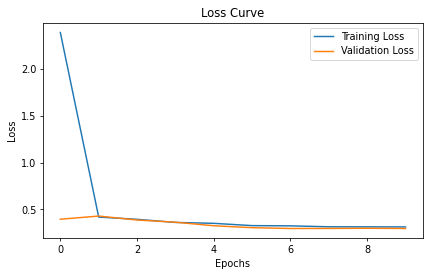

In [19]:
# Plotting the Loss
epochs = range(EPOCHS)
plt.figure(figsize=(7,4), dpi=70)
plt.plot(epochs, train_loss_plot, label="Training Loss")
plt.plot(epochs, val_loss_plot, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

The Simple CNN from scratch, on the divergence between training and validation loss, reveals early signs of overfitting, suggesting that the model's limited architecture with only two convolutional layers struggles to learn generalizable features and instead begins memorizing specific training examples.

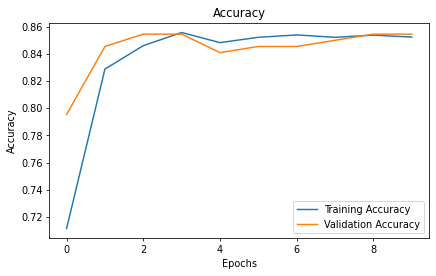

In [20]:
# Plotting the Accuracy
epochs = range(EPOCHS)
plt.figure(figsize=(7,4), dpi=70)
plt.plot(epochs, train_acc_plot, label="Training Accuracy")
plt.plot(epochs, val_acc_plot, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.show()

Both training and validation got a good accuracy and the gap between the them is little (approximately 2%), however, the validation results stopped improving, indicating that the simple architecture reached its learning capacity early and lacks the depth required to extract sophisticated features.

#### Making predictions for the first model

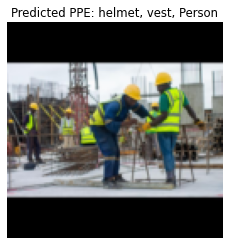

In [21]:
sample_img, _ = test_dataloader.dataset[0]
model_1.eval()
with torch.no_grad():
    pred = torch.sigmoid(model_1(sample_img.unsqueeze(0).to(device))[0])
pred_classes = [CLASS_NAMES[i] for i, v in enumerate(pred) if v > 0.5]
if "none" in pred_classes and any(c in pred_classes for c in CLASS_NAMES[:5]):
    pred_classes.remove("none")

img_np = np.array(sample_img.permute(1, 2, 0))
plt.figure(figsize=(7,4), dpi=70)
plt.imshow(img_np)
plt.axis('off')
plt.title("Predicted PPE: " + ", ".join(pred_classes))
plt.show()

### Transfer Learning

In [22]:
# Setting the pretrained weights
weights = torchvision.models.ResNet50_Weights.DEFAULT
weights

ResNet50_Weights.IMAGENET1K_V2

In [23]:
# Get the transform to be compatible with RestNet pretrained weights
resnet_transform = weights.transforms()
resnet_transform

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [24]:
# Setting the model with pretrained weights
model_2 = torchvision.models.resnet50(weights=weights).to(device)
model_2

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 207MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [25]:
summary(model=model_2,
        input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 1000]           --                   True
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   9,408                True
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   128                  True
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   True
│    └─Bottleneck (0)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   True
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     4,096                True
│    │    └─BatchN

In [26]:
# Freezing the base layers
for param in model_2.parameters():
    param.requires_grad = False

In [27]:
summary(model=model_2,
        input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 1000]           --                   False
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   (9,408)              False
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   (128)                False
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   False
│    └─Bottleneck (0)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   False
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     (4,096)              False
│    │    └─

###

In [28]:
# Adapting the model to 11 classes
NUM_CLASSES = 11
num_ftrs = model_2.fc.in_features
model_2.fc = nn.Linear(num_ftrs, NUM_CLASSES).to(device)


#### Setting up the loss and the optimizer for the second model

In [29]:
LEARNING_RATE = 0.001

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_2.parameters(), lr=LEARNING_RATE)

#### Training the second model

In [30]:
# Setting the seed
torch.manual_seed(42)
# Starting the timer
start_time = timer()

EPOCHS = 10

train_loss_plot = []
val_loss_plot = []
train_acc_plot = []
val_acc_plot = []

for epoch in tqdm(range(EPOCHS)):
    print(f"Epoch: {epoch+1}\n---------")
    train_loss, train_acc = train_step(
        data_loader=train_dataloader,
        model=model_2,
        loss_fn=criterion,
        optimizer=optimizer,
        device=device
    )
    val_loss, val_acc = test_step(
        data_loader=val_dataloader,
        model=model_2,
        loss_fn=criterion,
        device=device
    )

    train_loss_plot.append(train_loss.detach().cpu().numpy())
    val_loss_plot.append(val_loss.detach().cpu().numpy())
    train_acc_plot.append(train_acc.detach().cpu().numpy())
    val_acc_plot.append(val_acc.detach().cpu().numpy())

    print(f"Train loss: {train_loss:.4f} | Train accuracy: {train_acc:.2f}%")
    print(f"Test loss: {val_loss:.4f}  | Test accuracy: {val_acc:.2f}%\n")

# Ending the timer
end_time = timer()
# Printing the total time
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1
---------
Train loss: 0.5982 | Train accuracy: 0.72%
Test loss: 0.4053  | Test accuracy: 0.85%

Epoch: 2
---------
Train loss: 0.3926 | Train accuracy: 0.86%
Test loss: 0.3280  | Test accuracy: 0.86%

Epoch: 3
---------
Train loss: 0.3314 | Train accuracy: 0.86%
Test loss: 0.3041  | Test accuracy: 0.86%

Epoch: 4
---------
Train loss: 0.2931 | Train accuracy: 0.87%
Test loss: 0.2896  | Test accuracy: 0.87%

Epoch: 5
---------
Train loss: 0.2735 | Train accuracy: 0.88%
Test loss: 0.2795  | Test accuracy: 0.88%

Epoch: 6
---------
Train loss: 0.2525 | Train accuracy: 0.90%
Test loss: 0.2727  | Test accuracy: 0.86%

Epoch: 7
---------
Train loss: 0.2426 | Train accuracy: 0.91%
Test loss: 0.2659  | Test accuracy: 0.86%

Epoch: 8
---------
Train loss: 0.2198 | Train accuracy: 0.92%
Test loss: 0.2630  | Test accuracy: 0.87%

Epoch: 9
---------
Train loss: 0.2104 | Train accuracy: 0.92%
Test loss: 0.2609  | Test accuracy: 0.87%

Epoch: 10
---------
Train loss: 0.1991 | Train accuracy

#### Plotting the loss curve and accuracy for the second model

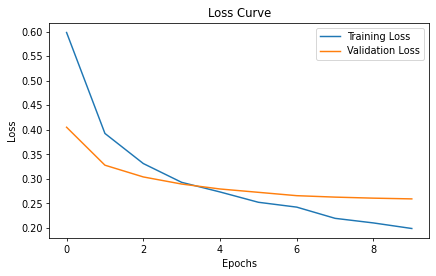

In [31]:
# Plotting the Loss
epochs = range(EPOCHS)
plt.figure(figsize=(7,4), dpi=70)
plt.plot(epochs, train_loss_plot, label="Training Loss")
plt.plot(epochs, val_loss_plot, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

ResNet50 showed promising results in terms of loss curves, with both training and validation loss decreasing smoothly together. We can noticed that the validation loss follows the training loss without diverging, indicating the model is learning instead of memorizing the data, a sign that transfer learning is working well.

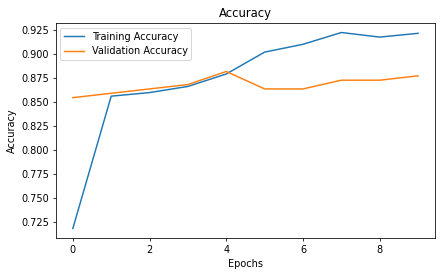

In [32]:
# Plotting the Accuracy
epochs = range(EPOCHS)
plt.figure(figsize=(7,4), dpi=70)
plt.plot(epochs, train_acc_plot, label="Training Accuracy")
plt.plot(epochs, val_acc_plot, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.show()

The accuracy results for ResNet50 were really strong, with both training and validation around 92%. Both accuracies stay close to each other during the 10 epochs, and this consistency shows that the model's deep architecture is doing a great job at learning relevant features for PPE detection, applying what it learned to new images.

#### Making predictions for the second model

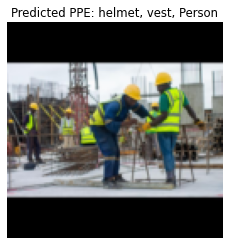

In [33]:
sample_img, _ = test_dataloader.dataset[0]
model_2.eval()
with torch.no_grad():
    pred = torch.sigmoid(model_2(sample_img.unsqueeze(0).to(device))[0])
pred_classes = [CLASS_NAMES[i] for i, v in enumerate(pred) if v > 0.5]
if "none" in pred_classes and any(c in pred_classes for c in CLASS_NAMES[:5]):
    pred_classes.remove("none")

img_np = np.array(sample_img.permute(1, 2, 0))
plt.figure(figsize=(7,4), dpi=70)
plt.imshow(img_np)
plt.axis('off')
plt.title("Predicted PPE: " + ", ".join(pred_classes))
plt.show()

### Saving the models

In [34]:
MODELS_DIR = os.path.join(DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)
print("Folder Models created.")
torch.save(model_1.state_dict(), "/content/ppe_dataset/AI_and_Safety_Engineering-main/models/model_1_weights.pth")
torch.save(model_2.state_dict(), "/content/ppe_dataset/AI_and_Safety_Engineering-main/models/model_2_weights.pth")
print("Models saved.")

Folder Models created.
Models saved.


## Part 2 -  Computer Vision with Object detection

### Creating the YAML configuration

In [35]:
DIR = "/content/ppe_dataset/AI_and_Safety_Engineering-main"

data_yaml = {
    "path": DIR,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 11,
    "names": [
        "helmet", "gloves", "vest", "boots", "goggles",
        "none", "Person", "no_helmet", "no_goggle", "no_gloves", "no_boots"
    ]
}

yaml_path = os.path.join(DIR, "ppe.yaml")
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("YAML file created.")



YAML file created.


### Training the third model

In [36]:
model_3 = YOLO("yolov8s.pt")

model_3.train(
    data=yaml_path,
    epochs=10,
    imgsz=640,
    batch=32,
    device=device,
    project=os.path.join(DIR, "models"),
    name="model_3",
    plots=True
)

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_dataset/AI_and_Safety_Engineering-main/ppe.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=model_32, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1299: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1301: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1748.0±663.6 MB/s, size: 48.3 KB)
train: Scanning /content/ppe_dataset/AI_and_Safety_Engineering-main/labels/train... 1132 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1132/1132 2.2Kit/s 0.5s
train: /content/ppe_dataset/AI_and_Safety_Engineering-main/images/train/image187.jpg: 1 duplicate labels removed
train: New cache created: /content/ppe_dataset/AI_and_Safety_Engineering-main/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 489.5±137.6 MB/s, size: 103.6 KB)
val: Scanning /content/ppe_dataset/AI_and_Safety_Engineering-main/labels/val... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 1.7Kit/s 0.1s
val: New cache created: /content/ppe_dataset/AI_and_Safety_Eng

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:238: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


       1/10      7.14G      2.057      3.833      2.037         71        640: 100% ━━━━━━━━━━━━ 36/36 1.4it/s 25.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3s/it 3.9s
                   all        143       1172      0.549      0.381      0.383      0.176

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:238: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


       9/10      7.03G      1.528     0.9536      1.497         93        640: 100% ━━━━━━━━━━━━ 36/36 1.9it/s 19.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.7it/s 1.7s
                   all        143       1172       0.49      0.543       0.55      0.279

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:238: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


      10/10      6.88G      1.485     0.9136      1.483         85        640: 100% ━━━━━━━━━━━━ 36/36 1.8it/s 19.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.6it/s 1.8s
                   all        143       1172      0.754       0.54      0.582      0.295

10 epochs completed in 0.066 hours.
Optimizer stripped from /content/ppe_dataset/AI_and_Safety_Engineering-main/models/model_32/weights/last.pt, 22.5MB
Optimizer stripped from /content/ppe_dataset/AI_and_Safety_Engineering-main/models/model_32/weights/best.pt, 22.5MB

Validating /content/ppe_dataset/AI_and_Safety_Engineering-main/models/model_32/weights/best.pt...
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,129,841 parameters, 0 gradients, 28.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1it/s 2.8s
           

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7deea24c6db0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

### Validating the model metrics

In [37]:
metrics = model_3.val()
print(metrics.box.map)

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,129,841 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1629.7±1223.6 MB/s, size: 181.3 KB)
val: Scanning /content/ppe_dataset/AI_and_Safety_Engineering-main/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 291.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.4it/s 3.8s
                   all        143       1172      0.744      0.542      0.584      0.296
                helmet        107        201      0.816      0.831      0.854      0.472
                gloves         68        136      0.745      0.772      0.803        0.4
                  vest        109        171      0.843      0.789      0.852      0.561
                 boots         64        151      0.668      0.733      0.796      0.463
             

####

### Ploting the results

In [38]:
df = pd.read_csv("/content/ppe_dataset/AI_and_Safety_Engineering-main/models/model_3/results.csv")

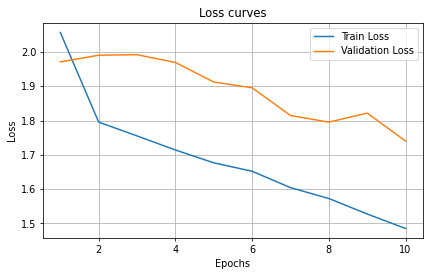

In [39]:
# Plotting Loss curves
plt.figure(figsize=(7,4), dpi=70)
plt.plot(df["epoch"], df["train/box_loss"], label="Train Loss")
plt.plot(df["epoch"], df["val/box_loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.grid()
plt.show()


The training and validation loss curves stay very close together during the entire process, with almost no signs of the model overfitting. This stability suggests that YOLOv8 is learning in a balanced way.

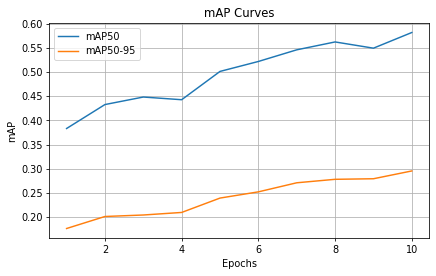

In [40]:
# Plotting mAP curves
plt.figure(figsize=(7,4), dpi=70)
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")

plt.xlabel("Epochs")
plt.ylabel("mAP")
plt.title("mAP Curves")
plt.legend()
plt.grid()
plt.show()


The mAP50 and the mAP50-95, both metrics kept increasing across all epochs without flattening out, suggesting the model was still actively learning and could even achieve better results perhaps with more training time. It was used 10 epochs, like the other two models, to compare them.

### Prediction on Test Set

In [41]:
test_path = os.path.join(DIR, "images/test")

model_3.predict(
    source=test_path,
    save=True,
    conf=0.35, # confidence threshold
    project=os.path.join(DIR, "models/model_3"),
    name="predictions"
)


image 1/141 /content/ppe_dataset/AI_and_Safety_Engineering-main/images/test/image1.jpeg: 640x640 1 helmet, 1 vest, 1 Person, 16.3ms
image 2/141 /content/ppe_dataset/AI_and_Safety_Engineering-main/images/test/image10.jpeg: 640x640 3 vests, 3 bootss, 3 Persons, 16.3ms
image 3/141 /content/ppe_dataset/AI_and_Safety_Engineering-main/images/test/image1003.jpg: 640x640 1 helmet, 2 glovess, 1 vest, 2 bootss, 1 goggles, 1 Person, 16.3ms
image 4/141 /content/ppe_dataset/AI_and_Safety_Engineering-main/images/test/image1007.jpg: 640x640 1 helmet, 2 glovess, 1 vest, 2 bootss, 1 goggles, 1 Person, 16.3ms
image 5/141 /content/ppe_dataset/AI_and_Safety_Engineering-main/images/test/image1009.jpg: 640x640 1 helmet, 1 gloves, 1 vest, 2 bootss, 1 Person, 16.3ms
image 6/141 /content/ppe_dataset/AI_and_Safety_Engineering-main/images/test/image1014.jpg: 640x640 1 helmet, 2 glovess, 1 vest, 2 bootss, 1 goggles, 1 Person, 16.2ms
image 7/141 /content/ppe_dataset/AI_and_Safety_Engineering-main/images/test/imag

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'helmet', 1: 'gloves', 2: 'vest', 3: 'boots', 4: 'goggles', 5: 'none', 6: 'Person', 7: 'no_helmet', 8: 'no_goggle', 9: 'no_gloves', 10: 'no_boots'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
  

### Making predictions for the third model


image 1/1 /content/ppe_dataset/AI_and_Safety_Engineering-main/images/test/image956.jpg: 640x640 1 helmet, 2 glovess, 1 vest, 3 bootss, 1 goggles, 1 Person, 9.4ms
Speed: 2.8ms preprocess, 9.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


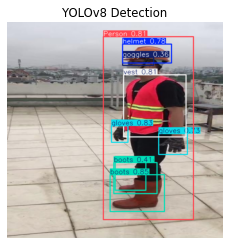

In [42]:
test_images = os.listdir(test_path)
sample = random.choice(test_images)
sample_path = os.path.join(test_path, sample)

result = model_3.predict(sample_path)[0]
annotated = result.plot()
annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7,4), dpi=70)
plt.imshow(annotated)
plt.axis("off")
plt.title("YOLOv8 Detection")
plt.show()


## Conclusion

This project explored three distinct approaches using deep learning architectures for PPE detection: a Simple CNN from scratch, ResNet50 using transfer learning, and YOLOv8. The Simple CNN from scratch served as a baseline model achieving approximately 85% accuracy but showed limited generalization, while ResNet50 delivered the highest multi-label classification accuracy at 92% through transfer learning. In the other hand, YOLOv8 presented the most practical solution for real-world applications, providing not only the classification but also the detected localization of PPE items. Despite ResNet50’s higher accuracy, Yolov8 is the best and recommended choice for monitoring PPE, detecting and localizing them effectively.

## Dowloading all files and folders

In [43]:
# Zip the entire project
import shutil
shutil.make_archive("/content/ppe_project", "zip", DIR)

from google.colab import files
files.download("/content/ppe_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>